<a href="https://colab.research.google.com/github/speleos/OptoDAS_processor/blob/main/SUBMERSE_workshop_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In case that you use data from this Notebook as it is originally provided (network `3X2023`), do not forget to use the proper citation for attribution:

*   Afonso Loureiro (2024): GeoLab. GFZ Data Services. Dataset/DAS. doi:[10.14470/8K802502](https://doi.org/10.14470/8K802502)

First, we need to install all the necessary functions: `boto3` to access data archived in some S3 Object Storage, and `simpledas`, to parse and read OptoDAS raw data files. `obspy` will be needed to show how we can convert DAS data into common formats.
After you install `boto3`, the environment needs to be restarted.
Run the script again to finish installing the packages.

In [1]:
try:
    import boto3
    import obspy
    import simpleDAS
    print("Environment ready.")
except ImportError:
    print("Installing dependencies...")
    !pip install boto3 obspy git+https://github.com/ASN-Norway/simpleDAS.git

Installing dependencies...
  Cloning https://github.com/ASN-Norway/simpleDAS.git to /tmp/pip-req-build-le1uy9va
  Running command git clone --filter=blob:none --quiet https://github.com/ASN-Norway/simpleDAS.git /tmp/pip-req-build-le1uy9va
  Resolved https://github.com/ASN-Norway/simpleDAS.git to commit a62cac60cb2fa9896270f9524915ec3b397ed663
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Let's import some libraries

In [2]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import os
from datetime import datetime, timedelta
from h5py import File
from matplotlib import pyplot as plt
import numpy as np
import simpledas
from simpledas import h5pydict
import obspy
import h5py
import scipy.signal as sps
from IPython.display import Image


It is very important to define who is actually hosting the data. Most of the examples you will find will be hosted in Amazon, but your Universities could also be providers of the S3 service.

In [3]:
endpoint = 'https://s3.gfz-potsdam.de/'

Within `boto3` there are 2 ways to operate on the buckets and objects. Through a `resource` or a `client`. In this example below we use the `resource` to get the data.

In [4]:
s3r = boto3.resource('s3', endpoint_url=endpoint, config=Config(signature_version=UNSIGNED))

Pay attention to the `UNSIGNED` value in the configuration. In this particular case, you will access data that does not require authentication. This is unusual in the S3 world. Usually you will be given a pair of keys (credentials) to operate with the service provider.

---

Once the `resource` is created, you can define the objects to operate with.
For instance, the `Bucket` where the 3X2023 data (GeoLab Madeira) are hosted.

In [5]:
bucket = s3r.Bucket('gc.3x2023')

Let's define the time window to download.

In [6]:
uncorrected_starttime = datetime(2023, 10, 29, 4, 50, 00)
uncorrected_endtime = datetime(2023, 10, 29, 4, 51, 10)

clock_offset=150 # positive values mean that the DAS clock is behind
starttime = uncorrected_starttime + timedelta(seconds=clock_offset)
endtime = uncorrected_endtime + timedelta(seconds=clock_offset)

print(f'Corrected start and end times: {starttime} - {endtime}')

Corrected start and end times: 2023-10-29 04:52:30 - 2023-10-29 04:53:40


Create auxiliary variables to loop through objects and keep the ones that lie within the time window. Here, we will check all objects that were created in the hour of the time window.

OptoDAS save a files every 10 seconds, and they are named according to the hour of the first sample, in directories named according to the date.

Example: ./DATA/20231029/dphi/045200.hdf5 corresponds to a file starting at 04:52:00 on 2023/10/29. The folder dphi indicates that we are dealing with phase differences ($dϕ$).

In [7]:
prefix = starttime.strftime('%Y%m%d/dphi/%H')
h5start = starttime.strftime('%Y%m%d/dphi/%H%M%S.h5')
h5end = endtime.strftime('%Y%m%d/dphi/%H%M%S.h5')
files = list()
prevfile = None

Loop through `objects` and always add a previous file to keep the beginning of the time window. Stop as soon as the time window is gone. After the loop, add the last file that is missing.

In [8]:
for obj in bucket.objects.filter(Prefix=prefix):
  # If time window is already gone then break
  if h5end < obj.key:
    break
  # If we are in the time window
  if h5start <= obj.key <= h5end:
    print(prevfile)
    files.append(prevfile)
  prevfile = obj.key

# If there was a file still pending
if prevfile is not None:
  files.append(prevfile)
  print(prevfile)


20231029/dphi/045229.hdf5
20231029/dphi/045239.hdf5
20231029/dphi/045249.hdf5
20231029/dphi/045259.hdf5
20231029/dphi/045309.hdf5
20231029/dphi/045319.hdf5
20231029/dphi/045329.hdf5
20231029/dphi/045339.hdf5


Use the `download_file` method to get some object(s) and save it physically in your local computer. Then, open it and extract the channel you want to display.

In [9]:
data_folder = "./DATA/"
for f in files:
    # 1. Create the full local path e.g., `./DATA/dphi/20231029/dphi/045229.hdf5`
    local_full_path = os.path.join(data_folder, f)

    # 2. Check if file already exists
    if os.path.exists(local_full_path):
        print(f"Skipping: {f} already exists at {local_full_path}")
        continue  # Moves to the next file in the list

    # 3. Extract the directory part for folder creation
    local_folder = os.path.dirname(local_full_path)

    # 4. Create the directories
    os.makedirs(local_folder, exist_ok=True)

    # 5. Download the data
    print(f"Downloading file: {f}")
    try:
        bucket.download_file(Key=f, Filename=local_full_path)
        print("Download complete.")
    except Exception as e:
        print(f"Error downloading {f}: {e}")

Download complete.
Download complete.
Download complete.
Download complete.
Download complete.
Download complete.
Download complete.
Download complete.


Let's check if the data are in the right place.

In [10]:
os.listdir("./DATA/20231029/dphi")


['045339.hdf5',
 '045319.hdf5',
 '045259.hdf5',
 '045249.hdf5',
 '045309.hdf5',
 '045239.hdf5',
 '045329.hdf5',
 '045229.hdf5']

Now we open the first file we downloaded and check if there's any data.

We'll choose a channel close to the beach, where we are bound to find waves.

extracting channel no.500, from file ./DATA/20231029/dphi/045229.hdf5


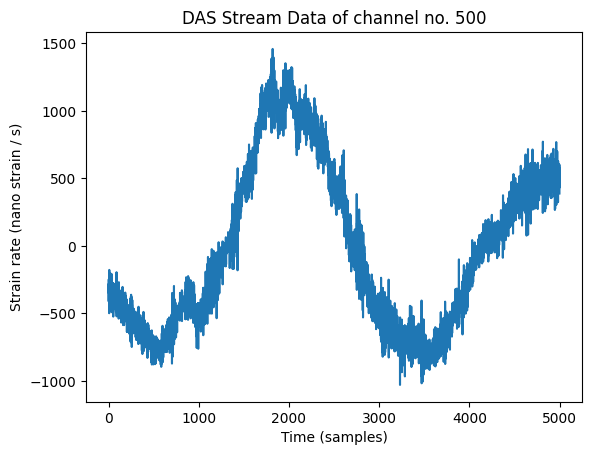

In [11]:
channel = 500
stream = np.array([])
filename=os.path.join(data_folder,files[0])
fi = File(filename)
print(f'extracting channel no.{channel}, from file {filename}')
stream = np.append(stream, fi['data'][:, channel])

plt.plot(stream)
plt.xlabel("Time (samples)")
plt.ylabel("Strain rate (nano strain / s)")
plt.title(f'DAS Stream Data of channel no. {channel}')
plt.show()

Each file is 10 seconds long. Notice how we have 5000 samples. According to the data report (DOI: [10.26443/seismica.v4i2.1482](https://doi.org/10.26443/seismica.v4i2.1482)), data were acquired at a 500 Hz sampling rate.

We see waves at about 10 s period, which is what we would expect.
**Data seems good!**

---

Now, we'll leverage simpledas to load more than just one channel.

Let's begin with retriving acquisition parameters from the header.

In [12]:
with h5py.File(os.path.join(data_folder,files[0]), "r") as hf_in:
            roi_step=hf_in['/demodSpec/roiDec'][0]
            first_chan = hf_in['/header/channels'][0]
            last_chan = hf_in['/header/channels'][-1]
            gps_status=hf_in['/monitoring/Gps/gpsStatus'][()]
            gauge_lenght=hf_in['/header/gaugeLength'][()]
            dx=hf_in['/header/dx'][()]
            channel_spacing=roi_step*dx
            sensitivity=hf_in['header/sensitivities/'][0][()]
            sensitivity_units=hf_in['header/sensitivityUnits'][()]

print(f'Channel length: {dx}')
print(f'Spatial decimation: {roi_step}')
print(f'Channel spacing: {channel_spacing}')
print(f'Gauge length: {gauge_lenght}')
print(f'Sensitivity: {sensitivity[0]} {sensitivity_units[0].decode("utf-8")}')
print(f'First channel: {first_chan}')
print(f'Last channel: {last_chan}')
print(f'GPS time status: {"Synchronized" if gps_status==0 else "Unsynchronized"}')

Channel length: 1.0213001907746815
Spatial decimation: 5
Channel spacing: 5.106500953873407
Gauge length: 10.213001907746815
Sensitivity: 9362208.901094029 rad/(strain*m)
First channel: 0
Last channel: 56895
GPS time status: Unsynchronized


Each OptoDAS channel is 1.02 m long. To save storage space, we skip over some (a spatial decimation). `roi_step` indicates how many channels we skip.

Notice also that GPS time wasn't available when the dataset was collected.


---

We have all the information we need. Let's get simpledas to build a file and channel list.

Note: although we defined start and end times to download date, simpledas requires a start time and a duration instead.
To avoid errors and hard-coded values in the code, we'll calculate the difference between both times.

In [13]:
duration_timedelta = endtime - starttime

dasfiles,chIndex,samples=simpledas.find_DAS_files(experiment_path=data_folder,\
                                               start=starttime,\
                                               duration=duration_timedelta,\
                                               show_header_info=True,\
                                               load_file_from_start=True)

-- Header info file: 045229.hdf5 --
	Experiment:            SN044_PHASE_26_10_2023
	File timestamp:        2023-10-29 04:52:29
	Type of data:          Phase rate per distance, unit: rad/(s*m)
	Sampling frequency:    500.00 Hz
	Data shape:            5000 samples x 11380 channels
	Gauge length:          10.2 m
	Sensitivities:         9.36e+06 rad/(strain*m)
	Regions of interest:   0:56895:5
-----------------------------------


Because we asked to show the header, simpledas prints out the most relevant information.

Note that the data are phase rate, not strain rate.

When we load the data, we can transform it into strain rate by multiplication with a constant $K$ that is stored in the file header.

$K=\frac{4 \pi \cdot n \cdot \xi}{\lambda}\quad,$

where $n$ is the effective refractive index of the fibre, $\lambda$ is the wavelength of the laser, $\xi$ is the fibre photoelastic effect parameter, equal to approximately 0.78.

Two cells above, we got the value of that constant directly from the file header (9362208.901094029 rad/(strain*m)).

If we do not say otherwise, simpledas will use this value and perform the conversion as it reads the files.

---


The function find_DAS_files returned a list of files and the available channels, as well as which samples to load, which will vary if we want to read entire files or just get the data within the start and end times.

Let's define a new channel range and load a window.
Since we need to specify every channel, we need to expand the list.

The channels are defined as arrays so that we can define multiple windows in the same loading procedure.

Example:

```
min_channel= [2000,5000]
max_channel= [4000,7000]
channel_step= [1,15]
```

Defines a channel range from 2000 to 4000, every channel, plus a second window from 5000 to 7000 at every 15 channels.

For our example, we will use a single block of channels.

In [14]:
# define start and end channels, and also an extra decimation step (if needed)

min_channel= [1900] # these are numbered according to the number of columns in the file
max_channel= [8000] # the internal channel numbering is different
channel_step= [1]

channels = []
for min_chan, max_chan, step_chan in zip(min_channel, max_channel, channel_step):
        top = (max_chan + 1) * roi_step if (max_chan + 1) < last_chan else last_chan
        channels.extend(np.arange(min_chan * roi_step, top, step_chan * roi_step))
        channels = np.array(channels)

# Although we number channels sequentially, internally they are still referenced
# to the 1.02 m channels, so we have to multiply them by the roi_step.

For a single channel range and no spatial decimation, this is equivalent to:
`channels=np.arange(min_channel*roi_step,max_channel*roi_step,roi_step)`



---



Let's use the new channel ranges and look for files.
Note that we now add the channels variable.

In [15]:
dasfiles,chIndex,samples=simpledas.find_DAS_files(experiment_path=data_folder,\
                                                  channels=channels,\
                                                  start=starttime,\
                                                  duration=duration_timedelta,\
                                                  show_header_info=True,\
                                                  load_file_from_start=True)

-- Header info file: 045229.hdf5 --
	Experiment:            SN044_PHASE_26_10_2023
	File timestamp:        2023-10-29 04:52:29
	Type of data:          Phase rate per distance, unit: rad/(s*m)
	Sampling frequency:    500.00 Hz
	Data shape:            5000 samples x 11380 channels
	Gauge length:          10.2 m
	Sensitivities:         9.36e+06 rad/(strain*m)
	Regions of interest:   0:56895:5
	6101 channels requested:[ 9500  9505  9510 ... 39990 39995 40000]
	6101 channels found:    [ 9500  9505  9510 ... 39990 39995 40000]
-----------------------------------


Note the channel numbering: 2000 x roi_step = 10000

Now we actually load the data.

We can also print the dataframe and get a glimpse of the values.

In [16]:
dfdas = simpledas.load_DAS_files(dasfiles, chIndex, samples,integrate=False)
dfdas

,9500,9505,9510,9515,9520,9525,9530,9535,9540,9545,...,39955,39960,39965,39970,39975,39980,39985,39990,39995,40000
2023-10-29 04:52:29.000,-2.005387e-07,-1.483986e-07,1.443879e-07,2.546842e-07,-5.013467e-08,3.208619e-08,7.620471e-08,-3.008081e-08,6.417238e-08,5.013467e-08,...,7.419932e-08,-4.812929e-08,-1.243340e-07,5.615084e-08,2.246033e-07,1.203232e-07,-1.945225e-07,-2.767434e-07,-1.925171e-07,4.612390e-08
2023-10-29 04:52:29.002,2.165818e-07,5.214006e-08,-2.366357e-07,-1.203232e-07,1.664471e-07,2.807542e-08,9.224780e-08,-1.804848e-08,-9.024242e-08,-3.008081e-08,...,1.604310e-08,8.222086e-08,7.018854e-08,1.403771e-08,-5.414545e-08,5.013467e-08,1.042801e-07,4.010774e-09,-1.504040e-07,-1.925171e-07
2023-10-29 04:52:29.004,-1.183178e-07,-4.812929e-08,1.263394e-07,3.609696e-08,-1.283448e-07,-9.826396e-08,-1.183178e-07,1.524094e-07,1.243340e-07,-3.409158e-08,...,0.000000e+00,6.818316e-08,-6.016161e-09,-7.620471e-08,-1.604310e-08,-6.818316e-08,-3.008081e-08,1.744687e-07,2.667165e-07,4.612390e-08
2023-10-29 04:52:29.006,-6.016161e-08,-5.615084e-08,-8.021548e-09,1.203232e-07,1.564202e-07,7.219393e-08,-4.010774e-08,-2.426518e-07,-7.219393e-08,1.865010e-07,...,1.062855e-07,-4.812929e-08,-8.021548e-08,5.013467e-08,1.042801e-07,-6.016161e-09,-4.612390e-08,-2.607003e-08,-1.243340e-07,0.000000e+00
2023-10-29 04:52:29.008,-1.123017e-07,-1.604310e-08,8.623164e-08,1.383717e-07,-3.008081e-08,-8.422625e-08,8.422625e-08,1.644417e-07,3.008081e-08,-1.403771e-07,...,-1.804848e-07,-1.483986e-07,1.203232e-08,1.203232e-08,-5.214006e-08,-2.205926e-08,1.082909e-07,1.143071e-07,1.183178e-07,-2.005387e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-29 04:53:38.990,-2.165818e-07,1.263394e-07,-9.024242e-08,-7.620471e-08,3.208619e-07,1.183178e-07,-4.411852e-08,1.143071e-07,3.609696e-08,-2.647111e-07,...,9.826396e-08,1.504040e-07,1.143071e-07,-5.214006e-08,-6.016161e-08,3.810235e-08,7.821009e-08,1.504040e-07,-2.005387e-08,-1.323555e-07
2023-10-29 04:53:38.992,2.707272e-07,-3.148457e-07,4.010774e-08,-1.804848e-08,-4.431905e-07,-1.143071e-07,4.411852e-08,-1.463932e-07,-1.203232e-08,3.108350e-07,...,-3.409158e-08,-1.423825e-07,-1.905118e-07,1.684525e-07,2.667165e-07,-6.617777e-08,-8.222086e-08,-7.419932e-08,-2.647111e-07,-1.042801e-07
2023-10-29 04:53:38.994,-2.466626e-07,3.910505e-07,1.123017e-07,8.222086e-08,4.592336e-07,1.885064e-07,-9.826396e-08,-2.406464e-08,-4.010774e-09,-2.647111e-07,...,2.647111e-07,2.065549e-07,5.815622e-08,-3.890451e-07,-4.010774e-07,1.303502e-07,1.263394e-07,7.620471e-08,2.065549e-07,-3.609696e-08
2023-10-29 04:53:38.996,3.389104e-07,-3.830289e-07,-2.346303e-07,3.409158e-08,-2.687219e-07,-2.747380e-07,-9.425319e-08,1.263394e-07,1.183178e-07,9.224780e-08,...,-4.090989e-07,-3.128404e-07,-1.203232e-07,5.314275e-07,6.878477e-07,-8.623164e-08,-4.251420e-07,-3.028134e-07,-3.469320e-07,-3.810235e-08


`simpledas` loads the data into a pandas dataframe, with time information for every sample, and apparent strain rate for each channel.

It is not phase rate because `simpledas` has already converted it.


---

One advantage of having loaded the DAS data with `simpledas` is that we can access the metadata directly instead of having to read it from the file header.

In the next cell, we leverage this to extract $dt$, $dx$, the starting time, and the shape of the data block. We already have these values as we loaded them to check if the data was good, but we can avoid that step for known datasets.

In [17]:
dt = dfdas.meta['dt']
dx = dfdas.meta['dx']
tstart = dfdas.meta['time']
nnx = dfdas.meta["dimensionSizes"][1]
nns = dfdas.meta["dimensionSizes"][0]

We can now downsample the data, as a sampling rate of 500 Hz puts a strain on computational resources (RAM, mostly).

Let's downsample it to 100 Hz, a downsampling factor of 5.

`scipy.signal.resample_poly` will take care of filtering the data before downsampling to avoid aliasing.

We will also copy the metadata from the original data to the downsampled version.

In [18]:
downsample_factor=5

print(f'Downsampling by a factor of {downsample_factor}')
Nt_in = dfdas.shape[0]
sig_downsampled = sps.resample_poly(dfdas, up=1, down=downsample_factor, axis=0, padtype='edge')
Nt_out = sig_downsampled.shape[0]
dt_out = dfdas.meta['dt'] * Nt_in / Nt_out
t = simpledas.create_time_axis(tstart, sig_downsampled.shape[0], dt_out)
meta_out = dfdas.meta.copy()
meta_out.update(dt=dt_out, time=tstart)
dfdas_downsampled = simpledas.DASDataFrame(sig_downsampled,\
                                         index=t,\
                                         columns=dfdas.columns,\
                                         meta=meta_out)

Downsampling by a factor of 5


To save memory, we replace dfdas with the downsampled version.

We need to also update some of the information we acquired from the header previously.

Note the change in time step and the number of samples. The number of channels remains the same.

In [19]:
dfdas=None
dfdas=dfdas_downsampled

old_dt = dt
old_nnx = nnx
old_nns = nns

dt = dfdas.meta['dt']
nnx = dfdas.meta["dimensionSizes"][1]
nns = dfdas.meta["dimensionSizes"][0]


print(f'dt: {old_dt} -> {dt}')
print(f'shape: {old_nnx}x{old_nns} -> {nnx}x{nns}')

dt: 0.002 -> 0.01
shape: 6101x35000 -> 6101x7000


OBSpy has many interesting tools already tested. We can leverage them instead of trying to implement our own.

However, OBSpy is written around the Stream() object. Fortunately, converting DAS data into a Stream is easy.



In [20]:
from obspy import UTCDateTime, Trace, Stream

st=Stream()
for channel in dfdas.columns[:]:
    tr = Trace()
    tr.data = dfdas[channel].to_numpy().astype(float)  # Convert to dType. default is float.
    tr.stats.starttime = UTCDateTime(dfdas.meta["time"])
    tr.stats.sampling_rate = 1/dfdas.meta["dt"]
    station_code = str(int(channel*dx)).zfill(5)
    tr.stats.station = station_code
    tr.stats.network = '3X'
    tr.stats.location = ''
    tr.stats.mseed = ['D']
    tr.stats.channel = 'HSF'
    tr.stats.distance = int(channel*dfdas.meta["dx"])
    st.append(tr)

Let's check if the conversion was successful

In [21]:
print(st)

6101 Trace(s) in Stream:

3X.09702..HSF | 2023-10-29T04:52:29.000000Z - 2023-10-29T04:53:38.990000Z | 100.0 Hz, 7000 samples
...
(6099 other traces)
...
3X.40852..HSF | 2023-10-29T04:52:29.000000Z - 2023-10-29T04:53:38.990000Z | 100.0 Hz, 7000 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


Let's use the Hilbert transform to extract the envelope of any signal in the selected data window. We'll define it as a function to use it again later. We will also define a plotting function.

In [22]:
def calculate_hilbert_envelope(data):
  # 1. Attempt to extract the real part; if it's a Stream object, this will fail.
  try:
    data = data.real
  except AttributeError:
    # 2. If it fails, we fall back to using 'data' directly
    data = data

  en = abs(sps.hilbert(data,axis=1)) # since we've applied an f-k-filter, we extract only the real part
  mdn = np.median(en, axis=1, keepdims=True)
  envelope = en / abs(mdn)
  return envelope

def plot_envelope(data,filename=None):
  fig = plt.figure(figsize=(4,6)) # (width,length)
  ax = plt.imshow(data.T,aspect='auto',\
                  extent=[dfdas.meta["dx"]*roi_step*min_channel[0]/1000,dfdas.meta["dx"]*roi_step*max_channel[0]/1000,\
                  0,\
                  dfdas.meta["dt"]*dfdas.meta["dimensionSizes"][0]],\
                  origin='lower',\
                  norm="log",\
                  cmap='Greys',\
                  vmin=0.7,\
                  vmax=2.0)

  plt.xlabel('Distance (km)')
  plt.ylabel('Time (s)')
  plt.title(f"{filename}\nStart time : {str(dfdas.meta["time"])}")
  plt.tight_layout()
  plt.show()
  plt.close()

  if filename != None:
    fig.savefig(f'{filename}.png',dpi=300, format='png', bbox_inches='tight', pad_inches=0.1)


Let's calculate and plot the envelope:

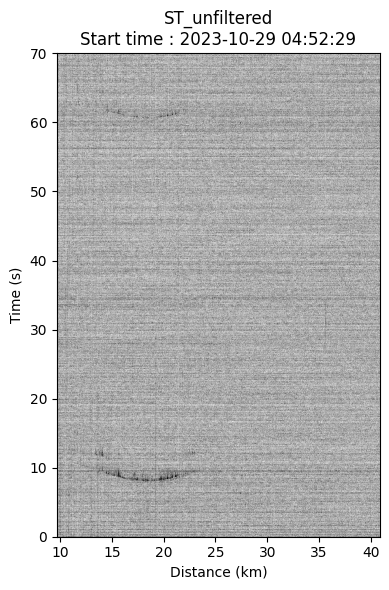

In [23]:
envelope=calculate_hilbert_envelope(st)
plot_envelope(envelope,filename="ST_unfiltered")

There is something visible, but we need to enhance the signal.

Let's apply a bandpass filter between 10 Hz and 40 Hz, and repeat the envelope calculation.

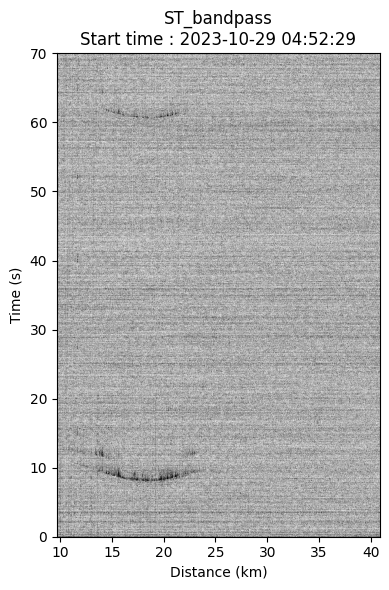

In [24]:
st.filter(type="bandpass",freqmin=10,freqmax=40,corners=8,zerophase=True)
envelope=calculate_hilbert_envelope(st)
plot_envelope(envelope,filename="ST_bandpass")

It has improved, but we can go one step further, and get rid of the noise that propagates mechanicaly along the fibre by f-k filtering anything that propagates below 1400 m/s.
To ensure we don't remove any interesting feature, we set `vmax` to 99999 m/s (practical $∞$).

We define the filter as a function, as we'll later use it again.

In [25]:
def fkfilter(data,vmin=1400,vmax=99999):
  from scipy import ndimage

  print("Return the Discrete Fourier Transform sample frequencies...")
  f = np.fft.fftfreq(nns,d=dt)
  k = np.fft.fftfreq(nnx,d=dx)

  f = np.fft.fftshift(f)
  k = np.fft.fftshift(k)

  print("Compute the 2-dimensional discrete Fourier Transform...")
  ft2 = np.fft.fft2(data)
  ft2s=np.fft.fftshift(ft2)
  del ft2

  print("Return a list of coordinate matrices from coordinate vectors...")
  F,K = np.meshgrid(f,k)
  del f, k

  # Change null values to very small ones to be able to divide afterwards.
  K = np.where(K==0, 1e-10, K)
  C = F/K

  print("Create filter mask...")
  # Create a mask of zeros in the same shape as C.
  filt = np.zeros(C.shape)
  # Create a mask to "mute" entries by replacing zeros with ones where C is in the desired range.
  condition = np.logical_and(np.abs(C) >= vmin, np.abs(C) <= vmax)
  filt[condition] = 1.

  # Blur mask.
  filt_blur = ndimage.gaussian_filter(filt, sigma=10)

  print("Apply mask...")
  ft2_filt = ft2s * filt_blur
  # del fts2
  ft2s_filt = np.fft.ifftshift(ft2_filt)
  del ft2_filt  # to save memory
  # Invert FFT.
  filtered_signal = np.fft.ifft2(ft2s_filt)

  return filtered_signal

Now we apply the F-K filter and recalculate the envelope.

Return the Discrete Fourier Transform sample frequencies...
Compute the 2-dimensional discrete Fourier Transform...
Return a list of coordinate matrices from coordinate vectors...
Create filter mask...
Apply mask...


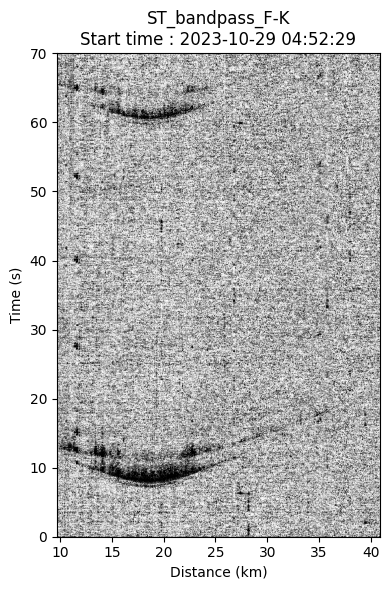

In [26]:
st=fkfilter(st,vmin=1400,vmax=99999)
envelope=calculate_hilbert_envelope(st)
plot_envelope(envelope,filename="ST_bandpass_F-K")

Congratulations, you've found whales. The hyperbolic features that dominate the image are blue whale calls. We can even see the multiple reflections. The tiny blips on the left side are fin whale B calls.

Now, let's try without resorting to OBSpy.

Since we can't leverage OBSpy directly for the filtering, we have to design a bandpass, zero-phase filter using scipy.

In [27]:
from scipy.signal import butter, sosfiltfilt

# Use Second-Order Sections (SOS) for better numerical stability
sos = butter(5, [10, 40], analog=False, btype='bandpass', fs=1/dt, output='sos')

# sosfiltfilt applies the filter forward and backward to keep phase at 0
filtered_signal = sosfiltfilt(sos, dfdas.values.astype(float).T)

The rest of the process is similar, we use the functions we've defined before.

Return the Discrete Fourier Transform sample frequencies...
Compute the 2-dimensional discrete Fourier Transform...
Return a list of coordinate matrices from coordinate vectors...
Create filter mask...
Apply mask...


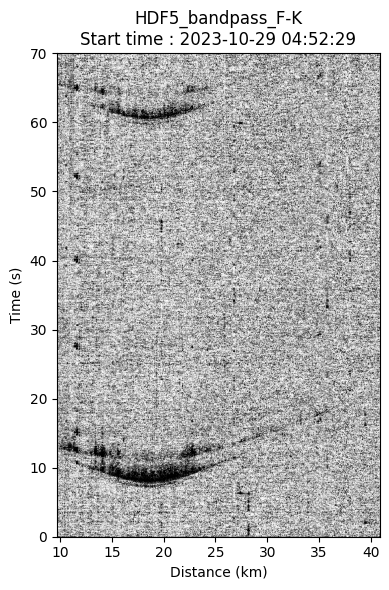

In [28]:
filtered_signal=fkfilter(filtered_signal,vmin=1400,vmax=99999)
envelope=calculate_hilbert_envelope(filtered_signal)
plot_envelope(envelope,"HDF5_bandpass_F-K")

Compare this image with Figure 16 from Loureiro et al. 2025.

---
We can look at the images more closely by uncommenting the commands below.

In [32]:
st=None

In [29]:
#Image("./ST_unfiltered.png")
#Image("./ST_bandpass.png")
#Image("./ST_bandpass_F-K.png")
#Image("./HDF5_bandpass_F-K.png")

We can also annotate the image. The following example is only correct for the original time and channel range of the example.

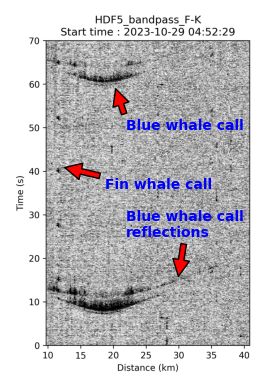

In [30]:
import matplotlib.image as mpimg

img = mpimg.imread('HDF5_bandpass_F-K.png')
fig, ax = plt.subplots()
ax.imshow(img)

ax.annotate('Blue whale call',
            xy=(500, 370),         # Coordinates for the arrow tip
            xytext=(550, 570),     # Coordinates for the text
            color='blue',
            weight='bold',
            arrowprops=dict(facecolor='red', shrink=0.05))
ax.annotate(f'Blue whale call\nreflections',
            xy=(800, 1280),         # Coordinates for the arrow tip
            xytext=(550, 1080),     # Coordinates for the text
            color='blue',
            weight='bold',
            arrowprops=dict(facecolor='red', shrink=0.05))
ax.annotate('Fin whale call',
            xy=(250, 750),         # Coordinates for the arrow tip
            xytext=(450, 850),     # Coordinates for the text
            color='blue',
            weight='bold',
            arrowprops=dict(facecolor='red', shrink=0.05))
plt.axis('off') # Hide the X/Y axis rulers
plt.savefig('HDF5_bandpass_F-K_annotated.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

Let's have a closer look at the coast.
We have to download more data, as one 70 s are good to spot whales, but not ideal for coastal processes.

We'll repeat the first cells, and use `simpledas` to load some channels.

In [46]:
uncorrected_starttime = datetime(2023, 10, 27, 18, 0, 0)
uncorrected_endtime = datetime(2023, 10, 27, 18, 30, 0)  # how much time do you need?

clock_offset=150 # positive values mean that the DAS clock is behind
starttime = uncorrected_starttime + timedelta(seconds=clock_offset)
endtime = uncorrected_endtime + timedelta(seconds=clock_offset)

print(f'Corrected start and end times: {starttime} - {endtime}')

prefix = starttime.strftime('%Y%m%d/dphi/%H')
h5start = starttime.strftime('%Y%m%d/dphi/%H%M%S.h5')
h5end = endtime.strftime('%Y%m%d/dphi/%H%M%S.h5')
files = list()
prevfile = None

for obj in bucket.objects.filter(Prefix=prefix):
  # If time window is already gone then break
  if h5end < obj.key:
    break
  # If we are in the time window
  if h5start <= obj.key <= h5end:
    print(prevfile)
    files.append(prevfile)
  prevfile = obj.key

# If there was a file still pending
if prevfile is not None:
  files.append(prevfile)
  print(prevfile)

  data_folder = "./DATA/"
for f in files:
    # 1. Create the full local path e.g., `./DATA/dphi/20231029/dphi/045229.hdf5`
    local_full_path = os.path.join(data_folder, f)

    # 2. Check if file already exists
    if os.path.exists(local_full_path):
        print(f"Skipping: {f} already exists at {local_full_path}")
        continue  # Moves to the next file in the list

    # 3. Extract the directory part for folder creation
    local_folder = os.path.dirname(local_full_path)

    # 4. Create the directories
    os.makedirs(local_folder, exist_ok=True)

    # 5. Download the data
    print(f"Downloading file: {f}")
    try:
        bucket.download_file(Key=f, Filename=local_full_path)
        print("Download complete.")
    except Exception as e:
        print(f"Error downloading {f}: {e}")


# define start and end channels, and also an extra decimation step (if needed)

min_channel= [400] # these are numbered according to the number of columns in the file
max_channel= [800] # the internal channel numbering is different
channel_step= [1]

channels = []
for min_chan, max_chan, step_chan in zip(min_channel, max_channel, channel_step):
        top = (max_chan + 1) * roi_step if (max_chan + 1) < last_chan else last_chan
        channels.extend(np.arange(min_chan * roi_step, top, step_chan * roi_step))
        channels = np.array(channels)

# we calculate the duration from the start and end times
duration_timedelta = endtime - starttime

dasfiles,chIndex,samples=simpledas.find_DAS_files(experiment_path=data_folder,\
                                                  channels=channels,\
                                                  start=starttime,\
                                                  duration=duration_timedelta,\
                                                  show_header_info=True,\
                                                  load_file_from_start=True)
dfdas = simpledas.load_DAS_files(dasfiles, chIndex, samples,integrate=False)

Corrected start and end times: 2023-10-27 18:02:30 - 2023-10-27 18:32:30
20231027/dphi/180229.hdf5
20231027/dphi/180239.hdf5
20231027/dphi/180249.hdf5
20231027/dphi/180259.hdf5
20231027/dphi/180309.hdf5
20231027/dphi/180319.hdf5
20231027/dphi/180329.hdf5
20231027/dphi/180339.hdf5
20231027/dphi/180349.hdf5
20231027/dphi/180359.hdf5
20231027/dphi/180409.hdf5
20231027/dphi/180419.hdf5
20231027/dphi/180429.hdf5
20231027/dphi/180439.hdf5
20231027/dphi/180449.hdf5
20231027/dphi/180459.hdf5
20231027/dphi/180509.hdf5
20231027/dphi/180519.hdf5
20231027/dphi/180529.hdf5
20231027/dphi/180539.hdf5
20231027/dphi/180549.hdf5
20231027/dphi/180559.hdf5
20231027/dphi/180609.hdf5
20231027/dphi/180619.hdf5
20231027/dphi/180629.hdf5
20231027/dphi/180639.hdf5
20231027/dphi/180649.hdf5
20231027/dphi/180659.hdf5
20231027/dphi/180709.hdf5
20231027/dphi/180719.hdf5
20231027/dphi/180729.hdf5
20231027/dphi/180739.hdf5
20231027/dphi/180749.hdf5
20231027/dphi/180759.hdf5
20231027/dphi/180809.hdf5
20231027/dphi/180

Full resolution data is too heavy, and the features we are interested in occur at periods longer than 1 s, so we dowsample the data.

However, to avoid numerical instabilities, we cannot directly downsample the data by a factor of 500. In practice, we never use factors above 10, so we need to do it in steps. For that, we adapt the previous downsampling routine to work through a series of downsampling steps.

In [47]:
downsample_factors=[5,5,5,4] # 500 Hz->100 Hz ; 100 Hz->25 Hz ; 25 Hz-> 5 Hz; 5 Hz-> 1 Hz

for downsample_factor in downsample_factors:
  print(f'Original sampling rate: {1/dfdas.meta["dt"]} Hz\nDownsampling by a factor of {downsample_factor}')
  Nt_in = dfdas.shape[0]
  sig_downsampled = sps.resample_poly(dfdas, up=1, down=downsample_factor, axis=0, padtype='edge')
  Nt_out = sig_downsampled.shape[0]
  dt_out = dfdas.meta['dt'] * Nt_in / Nt_out
  t = simpledas.create_time_axis(tstart, sig_downsampled.shape[0], dt_out)
  meta_out = dfdas.meta.copy()
  meta_out.update(dt=dt_out, time=tstart)
  dfdas = simpledas.DASDataFrame(sig_downsampled,\
                                          index=t,\
                                          columns=dfdas.columns,\
                                          meta=meta_out)
  print(f"New sampling rate: {1/dfdas.meta["dt"]} Hz")

Original sampling rate: 500.0 Hz
Downsampling by a factor of 5
New sampling rate: 100.0 Hz
Original sampling rate: 100.0 Hz
Downsampling by a factor of 5
New sampling rate: 20.0 Hz
Original sampling rate: 20.0 Hz
Downsampling by a factor of 5
New sampling rate: 4.0 Hz
Original sampling rate: 4.0 Hz
Downsampling by a factor of 4
New sampling rate: 1.0 Hz


In [ ]:
#just the dispersion curve and the theoretical curve